# Recommender analysis: explanations, uncertainty, and baselines

Companion to `recommender.ipynb` (core ranking + warm-start). This is the heavier paper-analysis layer:

- **SHAP** — which flow-text tokens / task metafeatures drive the ranker (paper 5.4).
- **Conformal uncertainty** — calibrated intervals + selective recommendation (5.5).
- **kNN baseline** — flow-text model vs the classic similar-tasks meta-learner (5.2).
- **`FlowRecommender` demo** — the usable API: metafeatures in, ranked flows out.

Heavy runs write to their own `results_recommender_*` dirs (gitignored).

## Configuration & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

import openml_flow as wf

CACHE_DIR   = 'minimal_cache_cc18'
FLOWS_CACHE = 'minimal_cache_cc18/flows.joblib'
AGG_MODE    = 'max'
MODEL_NAME  = 'extra_trees'   # best ranker (see recommender.ipynb model comparison)

CONFIGS = [
    {'name': 'tfidf_meta', 'text_mode': 'tfidf', 'use_task_metafeatures': True},
    {'name': 'tfidf_only', 'text_mode': 'tfidf', 'use_task_metafeatures': False},
    {'name': 'meta_only',  'text_mode': 'none',  'use_task_metafeatures': True},
]

bundle = wf.load_cc18_from_openml(cache=wf.DiskCache(CACHE_DIR))
flows  = wf.load_or_cache_flows(bundle['evals_df'], FLOWS_CACHE)
print('tasks:', bundle['tasks_df'].shape, '| flows:', len(flows))

tasks: (72, 19) | flows: 3073


## 1. What drives the ranker (SHAP)

`explain_ranker` fits the model on all data and runs TreeSHAP, splitting attribution into
`text::` vs `meta::` namespaces. Blue raises predicted accuracy, orange lowers it.

In [2]:
shap_out = wf.explain_ranker(
    flows=flows, tasks_df=bundle['tasks_df'], evals_df=bundle['evals_df'],
    text_mode='tfidf', use_task_metafeatures=True, model_name=MODEL_NAME,
    shap_background_size=200, shap_eval_size=400, top_n=30,
    cache_dir=CACHE_DIR, results_dir='results_recommender_shap',
)
print('namespace share of |SHAP|:')
display(shap_out['namespace_share'].round(4))

 14%|===                 | 57/400 [00:11<01:06]       

 16%|===                 | 63/400 [00:12<01:04]       

 17%|===                 | 69/400 [00:13<01:02]       

 19%|====                | 75/400 [00:14<01:00]       

 20%|====                | 80/400 [00:15<01:00]       

...

 97%|=================== | 387/400 [01:11<00:02]       

 98%|===================| 392/400 [01:12<00:01]       

100%|===================| 398/400 [01:13<00:00]       

namespace share of |SHAP|:


,namespace,mean_abs_shap,share
0,text,0.1643,0.5095
1,meta,0.1582,0.4905


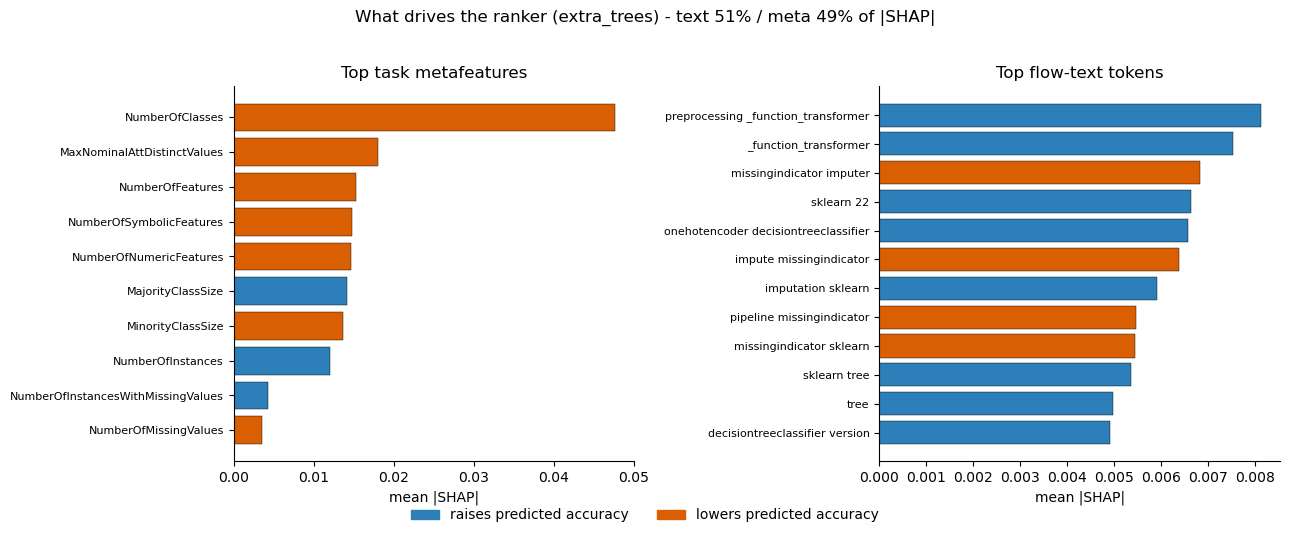

In [3]:
FIG = Path(shap_out['results_dir']) / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
g = shap_out['global_shap']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, ns) in zip(axes, [('Top task metafeatures', ['meta']),
                                  ('Top flow-text tokens', ['text', 'embedding'])]):
    sub = g[g.namespace.isin(ns)].head(12).iloc[::-1]
    colors = ['#2c7fb8' if s >= 0 else '#d95f02' for s in sub.signed_mean_shap]
    ax.barh(range(len(sub)), sub.mean_abs_shap, color=colors, edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([f.split('::', 1)[1] for f in sub.feature], fontsize=8)
    ax.set_xlabel('mean |SHAP|'); ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
fig.legend(handles=[Patch(color='#2c7fb8', label='raises predicted accuracy'),
                    Patch(color='#d95f02', label='lowers predicted accuracy')],
           loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
share = shap_out['namespace_share'].set_index('namespace')['share']
fig.suptitle(f"What drives the ranker ({MODEL_NAME}) - "
             f"text {share.get('text', 0):.0%} / meta {share.get('meta', 0):.0%} of |SHAP|", y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'shap_ranker.png', dpi=150, bbox_inches='tight')
fig.savefig(FIG / 'shap_ranker.pdf', bbox_inches='tight')
plt.show()

## 2. Confidence-aware recommendation (conformal)

Split-conformal intervals (group-disjoint calibration). Coverage should be near the target;
interval width then drives *selective recommendation* - abstain on low-confidence tasks.

In [4]:
conf = wf.run_conformal_evaluation(
    flows=flows, tasks_df=bundle['tasks_df'], evals_df=bundle['evals_df'],
    configs=CONFIGS, agg_mode=AGG_MODE, model_name=MODEL_NAME,
    cv_folds=5, alpha=0.1, calib_frac=0.25,
    cache_dir=CACHE_DIR, results_dir='results_recommender_conformal',
)
display(conf['coverage'][['experiment', 'alpha', 'target_coverage', 'coverage', 'mean_width', 'n']].round(4))

Conformal :: tfidf_meta (extra_trees, alpha=0.1) ...


Conformal :: tfidf_only (extra_trees, alpha=0.1) ...


Conformal :: meta_only (extra_trees, alpha=0.1) ...


/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rh

,experiment,alpha,target_coverage,coverage,mean_width,n
0,tfidf_meta,0.1,0.9,0.8573,0.4838,7961
1,tfidf_only,0.1,0.9,0.8837,0.6259,7961
2,meta_only,0.1,0.9,0.8209,0.5745,7961


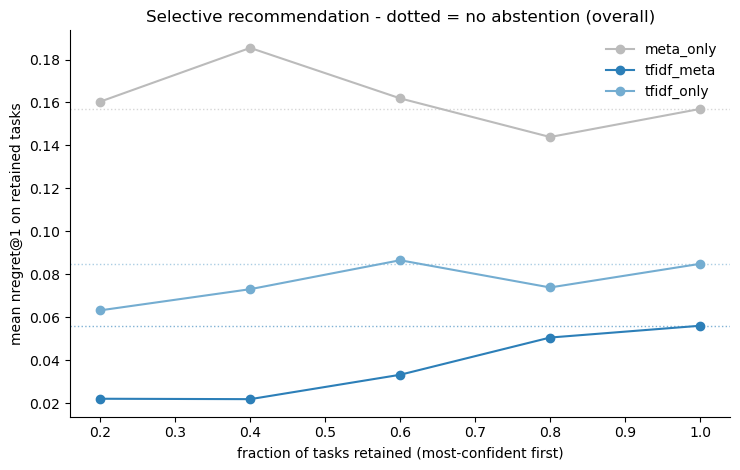

In [5]:
sel = conf['selective']
col = {'tfidf_meta': '#2c7fb8', 'tfidf_only': '#74add1', 'meta_only': '#bbbbbb'}
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for exp, gg in sel.groupby('experiment'):
    gg = gg.sort_values('retained_frac')
    ax.plot(gg.retained_frac, gg['nregret@1_selective'], marker='o', color=col.get(exp, '#333'), label=exp)
    ax.axhline(gg['nregret@1_overall'].iloc[0], color=col.get(exp, '#333'), ls=':', lw=1, alpha=0.6)
ax.set_xlabel('fraction of tasks retained (most-confident first)')
ax.set_ylabel('mean nregret@1 on retained tasks')
ax.set_title('Selective recommendation - dotted = no abstention (overall)')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
FIGc = Path(conf['results_dir']) / 'figures'; FIGc.mkdir(parents=True, exist_ok=True)
fig.tight_layout(); fig.savefig(FIGc / 'selective_recommendation.png', dpi=150)
fig.savefig(FIGc / 'selective_recommendation.pdf'); plt.show()

## 3. Flow-text model vs kNN meta-learner

`include_knn=True` adds the classic baseline: score flows by how they did on the k nearest
training tasks (dataset-metafeature similarity). The claim is that flow text beats task-similarity.

In [6]:
knn = wf.run_recommender_evaluation(
    flows=flows, tasks_df=bundle['tasks_df'], evals_df=bundle['evals_df'],
    configs=[{'name': 'tfidf_meta', 'text_mode': 'tfidf', 'use_task_metafeatures': True},
             {'name': 'meta_only',  'text_mode': 'none',  'use_task_metafeatures': True}],
    agg_mode=AGG_MODE, model_name=MODEL_NAME, cv_folds=5, n_random_shuffles=20,
    include_knn=True, knn_k=5,
    cache_dir=CACHE_DIR, results_dir='results_recommender_knn',
)
order = {'model': 0, 'knn': 1, 'global_default': 2, 'random': 3}
s = knn['summary'].sort_values(['experiment', 'method'],
        key=lambda cc: cc.map(order) if cc.name == 'method' else cc)
display(s[['experiment', 'method', 'nregret@1_mean', 'hit@1_mean', 'spearman_mean', 'ndcg@5_mean']].round(4))
print('Wilcoxon vs global_default (nregret@1):')
w = knn['wilcoxon']
display(w[(w.baseline == 'global_default') & (w.metric == 'nregret@1')]
        [['experiment', 'method', 'median_diff', 'win_rate', 'p_value']].round(4))

Recommender :: tfidf_meta (extra_trees, agg=max) ...


Recommender :: meta_only (extra_trees, agg=max) ...


/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = float(spearmanr(pred, true).correlation)
/Users/roman/Documents/Claude/code/workflows/openml_flow.py:1805: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rh

,experiment,method,nregret@1_mean,hit@1_mean,spearman_mean,ndcg@5_mean
2,meta_only,model,0.1570,0.0000,NaN,0.8437
1,meta_only,knn,0.1047,0.0833,0.6274,0.9191
0,meta_only,global_default,0.0946,0.0694,0.6846,0.9185
3,meta_only,random,0.2322,0.0090,0.0027,0.7743
6,tfidf_meta,model,0.0314,0.2222,0.7314,0.9687
5,tfidf_meta,knn,0.1047,0.0833,0.6274,0.9191
4,tfidf_meta,global_default,0.0946,0.0694,0.6846,0.9185
7,tfidf_meta,random,0.2322,0.0090,0.0027,0.7743


Wilcoxon vs global_default (nregret@1):


,experiment,method,median_diff,win_rate,p_value
0,meta_only,model,0.0353,0.1806,0.0000
1,meta_only,knn,0.0000,0.4167,0.5973
2,tfidf_meta,model,-0.0057,0.6389,0.0015
3,tfidf_meta,knn,0.0000,0.4167,0.5973


## 4. `FlowRecommender` demo - the usable API

Fit once, then hand it a new task's metafeatures and get ranked flows. (Here we fit on all data
and query an existing task's metafeatures for illustration.)

In [7]:
recommender = wf.FlowRecommender(model_name=MODEL_NAME, text_mode='tfidf', use_task_metafeatures=True)
recommender.fit(flows, bundle['tasks_df'], bundle['evals_df'], agg_mode=AGG_MODE, cache=wf.DiskCache(CACHE_DIR))

tasks_norm, meta_cols = wf.normalize_cc18_tasks(bundle['tasks_df'])
example = tasks_norm.iloc[0]
task_mf = {c: example[c] for c in meta_cols}
print(f"Example task: {example['task_name']} (task_id={example['task_id']})")
print('metafeatures:', {k: round(float(v), 1) for k, v in task_mf.items()})

top = recommender.recommend(task_mf, top_k=10)
display(top.round(4))

Example task: kr-vs-kp (task_id=3)
metafeatures: {'MajorityClassSize': 1669.0, 'MaxNominalAttDistinctValues': 3.0, 'MinorityClassSize': 1527.0, 'NumberOfClasses': 2.0, 'NumberOfFeatures': 37.0, 'NumberOfInstances': 3196.0, 'NumberOfInstancesWithMissingValues': 0.0, 'NumberOfMissingValues': 0.0, 'NumberOfNumericFeatures': 0.0, 'NumberOfSymbolicFeatures': 37.0}


,flow_id,flow_name,predicted_accuracy
0,12736,sklearn.pipeline.Pipeline(simpleimputer=sklear...,0.9978
1,16347,sklearn.pipeline.Pipeline(simpleimputer=sklear...,0.9978
2,6970,sklearn.pipeline.Pipeline(imputation=openmlstu...,0.9978
3,8817,sklearn.pipeline.Pipeline(columntransformer=sk...,0.9978
4,6954,sklearn.pipeline.Pipeline(imputation=openmlstu...,0.9973
5,6952,sklearn.pipeline.Pipeline(imputation=openmlstu...,0.9973
6,7103,sklearn.pipeline.Pipeline(imputation=openmlstu...,0.9973
7,17373,sklearn.model_selection._search_successive_hal...,0.9969
8,8885,sklearn.pipeline.Pipeline(imputation=preproces...,0.9969
9,7684,sklearn.ensemble.forest.RandomForestClassifier,0.9966
